In [1]:
import numpy as np
import matplotlib.pyplot as pl
import scanpy as sc
sc.settings.verbosity = 3 # verbosity: errors (0), warnings (1), info (2), hints (3)
# low dpi (dots per inch) yields small inline figures
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")
adata = sc.datasets.paul15()
adata

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 9.82M/9.82M [00:02<00:00, 4.63MB/s]


AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

running recipe zheng17
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
    finished (0:00:00)
computing PCA
    with n_comps=50


/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/scanpy/preprocessing/_recipes.py:185: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = filter_genes_dispersion(


    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 20


2026-04-07 15:00:15.041095: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-07 15:00:15.097575: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 15:00:16.907910: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 15:00:21.884097: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fr', graph_drawing coordinates (adata.obsm) (0:00:03)


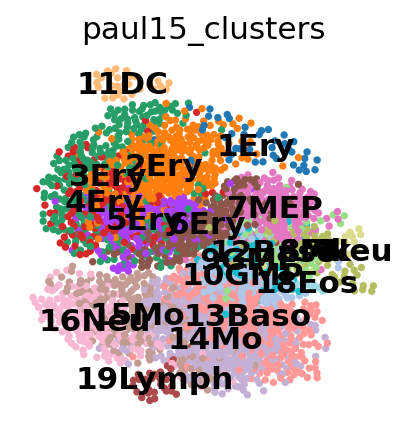

In [2]:
# preprocessing
sc.pp.recipe_zheng17(adata)
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=4, n_pcs=20)
sc.tl.draw_graph(adata)
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

In [3]:
adata

AnnData object with n_obs × n_vars = 2730 × 999
    obs: 'paul15_clusters', 'n_counts_all'
    var: 'n_counts', 'mean', 'std'
    uns: 'iroot', 'log1p', 'pca', 'neighbors', 'draw_graph', 'paul15_clusters_colors'
    obsm: 'X_pca', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## optional: denoise

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         1.         0.9989645  0.99678516 0.9944012  0.9892853
     0.9882636  0.9871257  0.98383176 0.9829755  0.97893244 0.9768993
     0.9744091  0.9727856  0.9661874 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fr', graph_drawing coordinates (adata.obsm) (0:00:03)


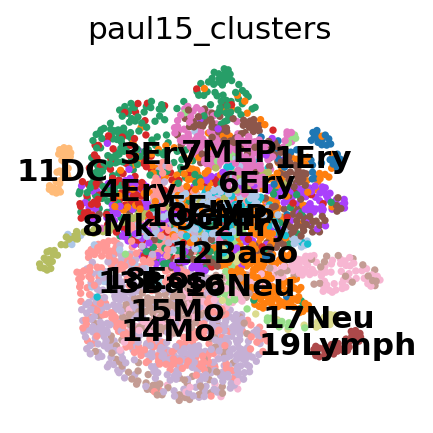

In [4]:
# represent it in diffusion map space (and not in PCA space) for denoise
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")
sc.tl.draw_graph(adata)
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

## Clustering and PAGA

In [5]:
sc.tl.leiden(adata)

running Leiden clustering


/scratch/slurm-8487889/ipykernel_2200895/3467744858.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


    finished: found 34 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


In [6]:
sc.tl.paga(adata, groups="leiden")
adata

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


AnnData object with n_obs × n_vars = 2730 × 999
    obs: 'paul15_clusters', 'n_counts_all', 'leiden'
    var: 'n_counts', 'mean', 'std'
    uns: 'iroot', 'log1p', 'pca', 'neighbors', 'draw_graph', 'paul15_clusters_colors', 'diffmap_evals', 'leiden', 'paga', 'leiden_sizes'
    obsm: 'X_pca', 'X_draw_graph_fr', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [7]:
adata.obs

,paul15_clusters,n_counts_all,leiden
W31105,7MEP,0.181912,3
W31106,15Mo,1.317186,0
W31107,3Ery,2.395774,18
W31108,15Mo,2.311775,14
W31109,3Ery,2.682298,18
...,...,...,...
W39164,2Ery,2.511209,9
W39165,13Baso,1.830971,15
W39166,7MEP,0.228292,3
W39167,15Mo,1.675857,14


--> added 'pos', the PAGA positions (adata.uns['paga'])


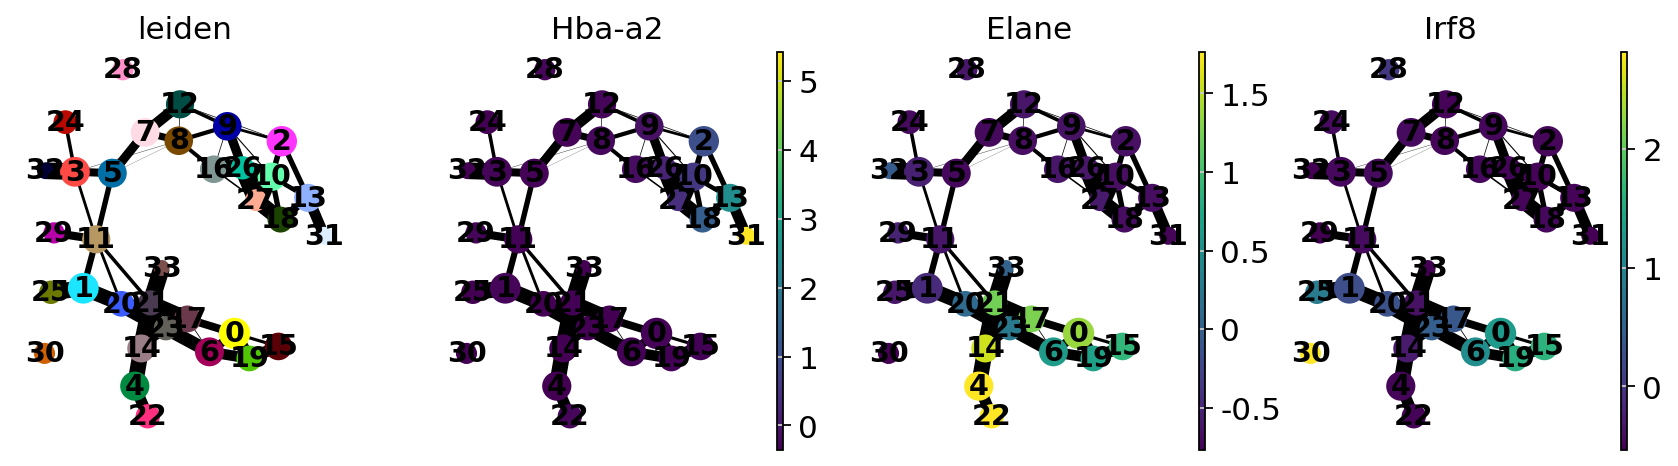

In [8]:
sc.pl.paga(adata, color=["leiden", "Hba-a2", "Elane", "Irf8"])

In [9]:
adata.obs["leiden"].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33'],
      dtype='object')

In [10]:
adata.obs["leiden_anno"] = adata.obs["leiden"]
adata.obs["leiden_anno"]

W31105     3
W31106     0
W31107    18
W31108    14
W31109    18
          ..
W39164     9
W39165    15
W39166     3
W39167    14
W39168    26
Name: leiden_anno, Length: 2730, dtype: category
Categories (34, object): ['0', '1', '2', '3', ..., '30', '31', '32', '33']

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


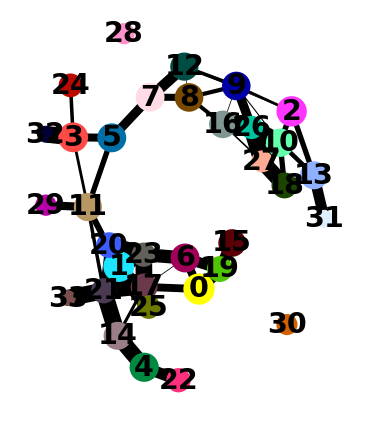

In [11]:
adata.obs["leiden_anno"].cat.rename_categories = [
    *["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    *["10/Ery", "11", "12", "13", "14", "15"],
    *["16/Stem", "17", "18"],
    *[
        "19/Neu",
        "20/Mk",
        "21",
    ],
    *["22/Baso", "23", "24/Mo"],
]

sc.tl.paga(adata, groups="leiden_anno")
sc.pl.paga(adata, threshold=0.03)

## Recomputing the embedding using PAGA-initialization

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fr', graph_drawing coordinates (adata.obsm) (0:00:01)


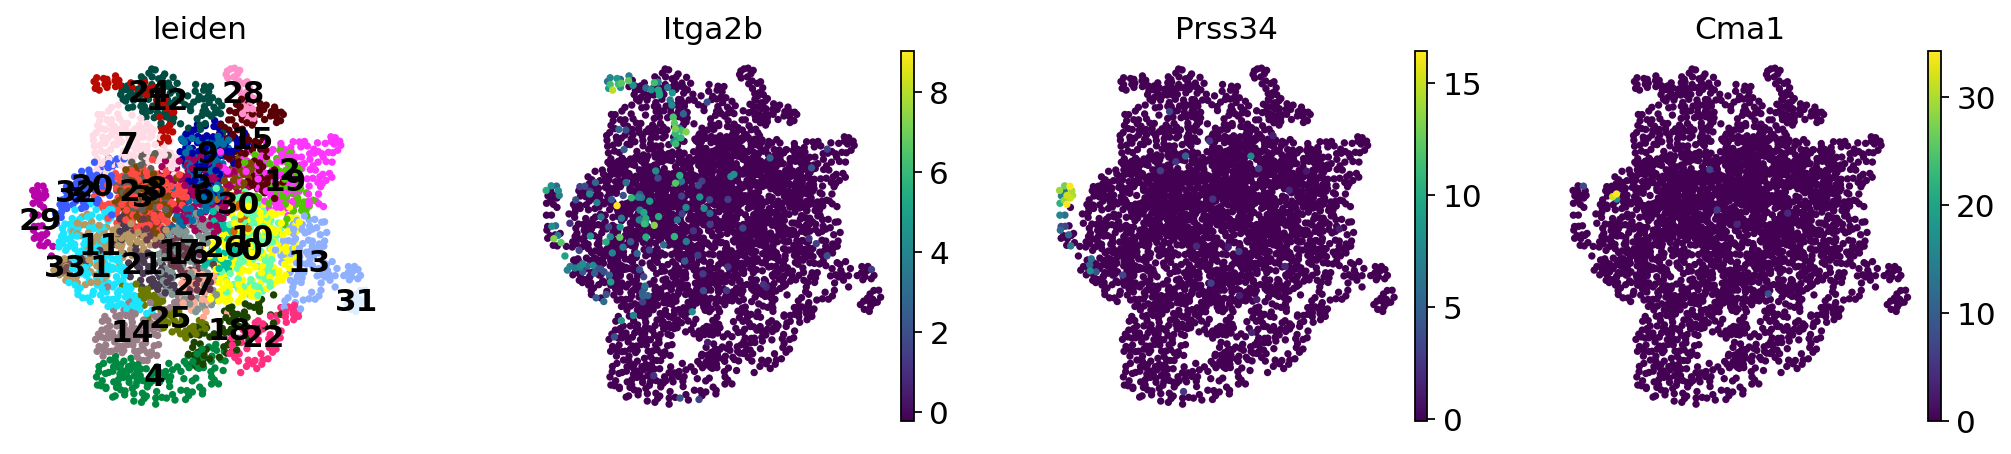

In [12]:
sc.tl.draw_graph(adata, init_pos="paga")
sc.pl.draw_graph(
    adata, color=["leiden", "Itga2b", "Prss34", "Cma1"], legend_loc="on data"
)

## 'fa2' do not support py 3.9+

In [13]:
adata

AnnData object with n_obs × n_vars = 2730 × 999
    obs: 'paul15_clusters', 'n_counts_all', 'leiden', 'leiden_anno'
    var: 'n_counts', 'mean', 'std'
    uns: 'iroot', 'log1p', 'pca', 'neighbors', 'draw_graph', 'paul15_clusters_colors', 'diffmap_evals', 'leiden', 'paga', 'leiden_sizes', 'leiden_colors', 'leiden_anno_sizes', 'leiden_anno_colors'
    obsm: 'X_pca', 'X_draw_graph_fr', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'